In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Image negatives  

In [ ]:
image = cv2.imread(r"F:\DataSets\KneeXrayData\KneeXrayData\ClsKLData\kneeKL299\val\4\9997856L.png",0)
for i in range (image.shape[0]-1):
    for j in range (image.shape[1]-1):
        pixels = image[(i,j)];
        
        Pixel_r    = 255 - pixels[0] 
        Pixel_g  = 255 - pixels[1]
        Pixel_b   = 255 - pixels[2] 
        image[(i,j)] = [Pixel_r, Pixel_g, Pixel_b]
        
        
plt.imshow(image)
plt.show()

# Log Transformations

In [ ]:
c = 255/(np.log(1 + np.max(image)))

image = cv2.imread(r"F:\DataSets\KneeXrayData\KneeXrayData\ClsKLData\kneeKL299\val\4\9997856L.png",0)

for i in range (image.shape[0]-1):
    for j in range (image.shape[1]-1):
        pixels = image[(i,j)];
        
        log_r = c * np.log(1 + pixels[0])
        log_g = c * np.log(1 + pixels[1])
        log_b = c * np.log(1 + pixels[2])
        
        image[(i,j)] = [log_r, log_r, log_b];
        
plt.imshow(image)
plt.show()

# Gamma

In [ ]:
image = cv2.imread(r"F:\DataSets\KneeXrayData\KneeXrayData\ClsKLData\kneeKL299\val\4\9997856L.png",0)

for i in range (image.shape[0]-1):
    for j in range (image.shape[1]-1):
        pixels = image[(i,j)];
        
        gamma_r = np.array(255*(pixels[0] / 255) ** 2.2, dtype = 'uint8')
        gamma_g = np.array(255*(pixels[1] / 255) ** 2.2, dtype = 'uint8')
        gamma_b = np.array(255*(pixels[2] / 255) ** 2.2, dtype = 'uint8')
        
        image[(i,j)] = [gamma_r, gamma_g, gamma_b];
        
plt.imshow(image)
plt.show()

# contrast stretching

In [ ]:
def contrast_stretching(pix, r1, s1, r2, s2):
    if (pix < r1):
        return s1 / r1 * pix
    elif (r1 < pix and pix <= r2):
        return (s2-s1) / (r2-r1) * (pix - r1) + s1
    else:
        return (255-s2) / (255-r2) * (pix - r2) + s2

img = cv2.imread(r"F:\DataSets\KneeXrayData\KneeXrayData\ClsKLData\kneeKL299\val\4\9997856L.png",0)

# parameters
rMin = img.min()  #  The minimum value of the gray level of the original image 
rMax = img.max()  #  The maximum gray level of the original image 

r1, s1 = rMin, 0  # (x1,y1)
r2, s2 = rMax, 255  # (x2,y2)

contrast_stretching_vec = np.vectorize(contrast_stretching)
contrast_stretched = contrast_stretching_vec(img, r1, s1, r2, s2)

        
plt.imshow(contrast_stretched,cmap="gray")
plt.show()
plt.imshow(img,cmap="gray")
plt.show()

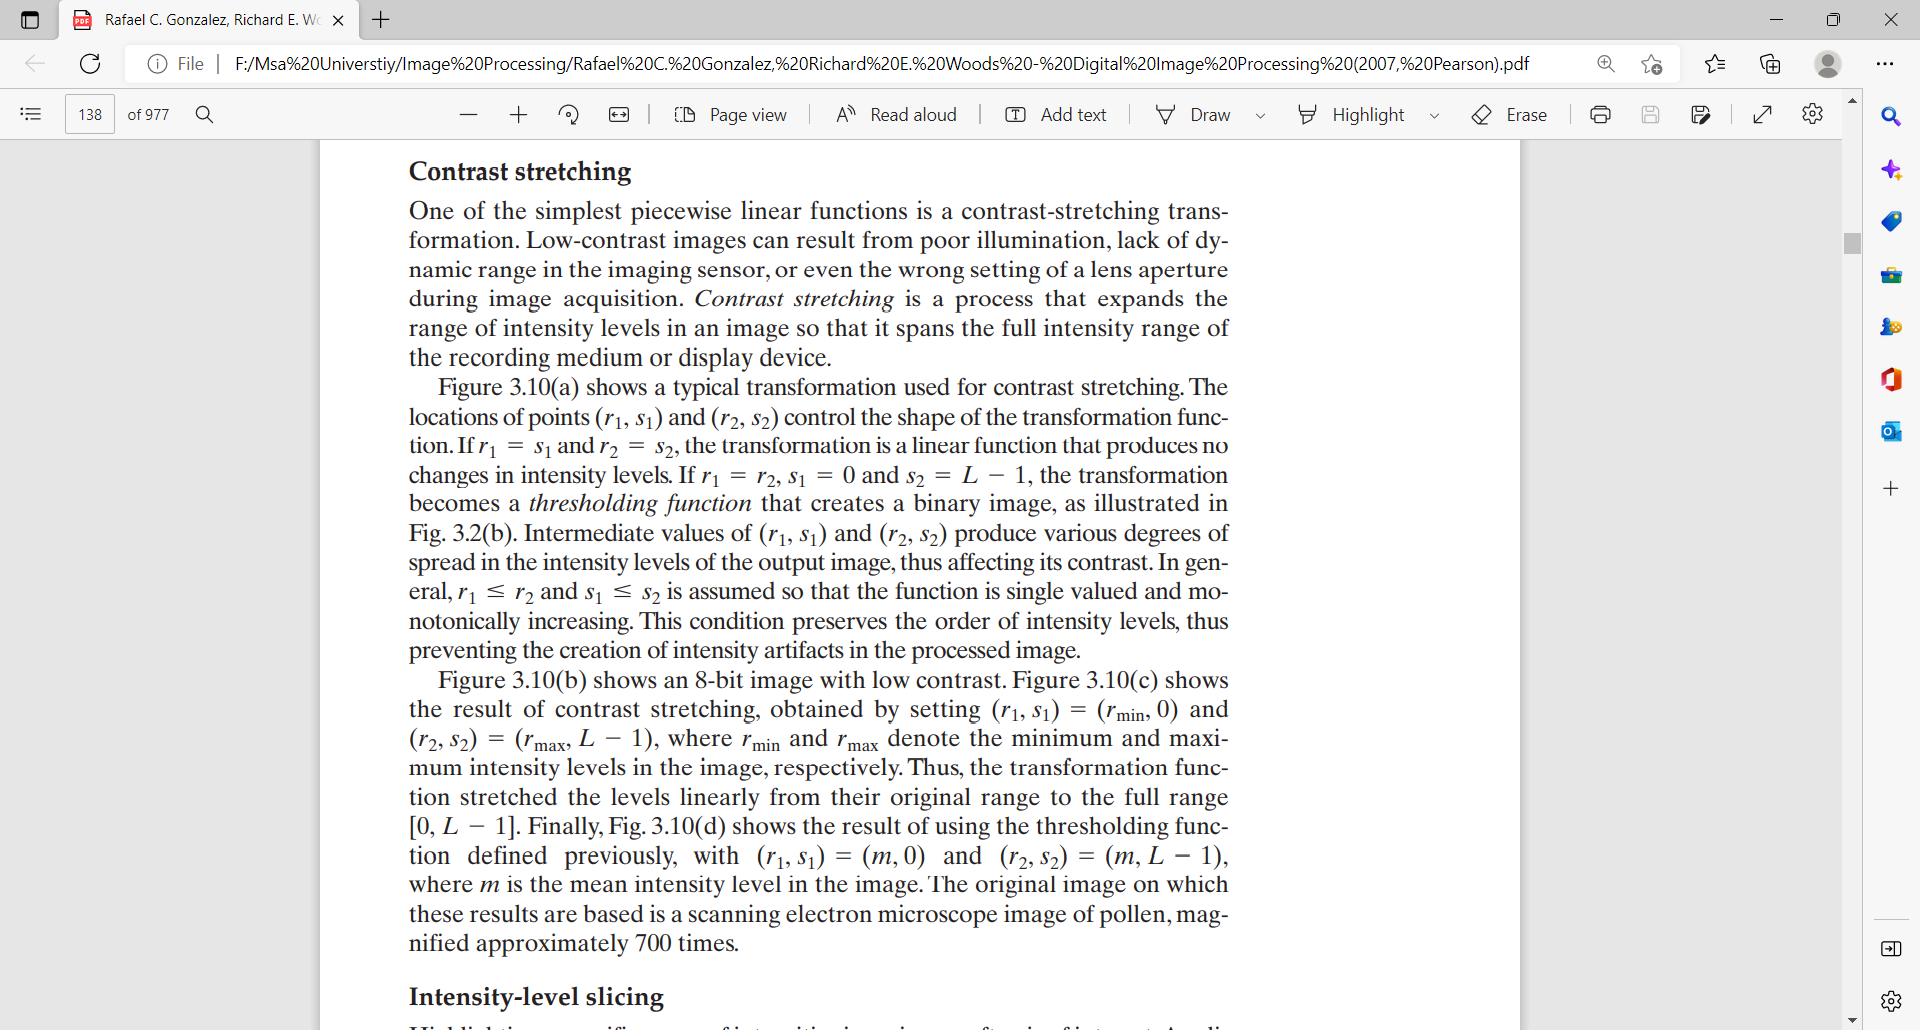

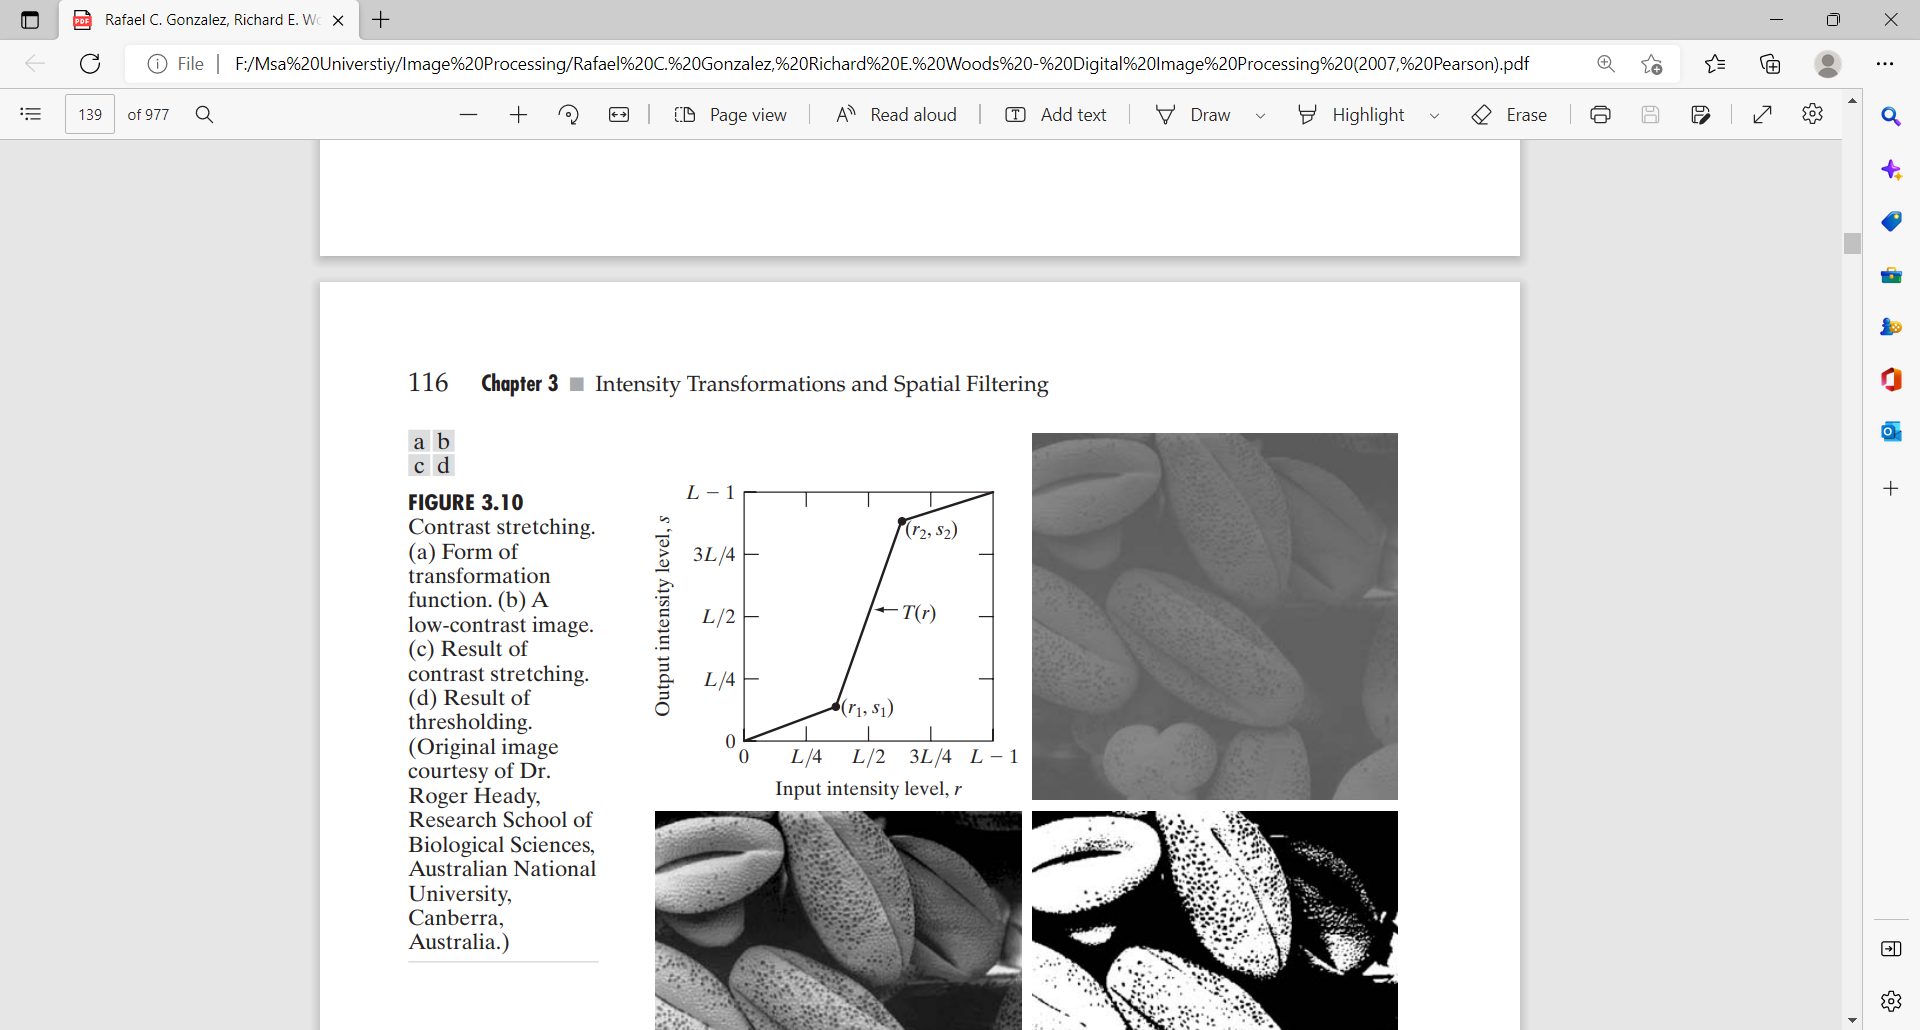

# Bit-plan

In [ ]:
# Read the image in greyscale
img = cv2.imread(r"F:\DataSets\KneeXrayData\KneeXrayData\ClsKLData\kneeKL299\val\4\9997856L.png",0)
# resize the imange to 700 * 500
img = cv2.resize(img, [700,500])
# convert the image to grayscale

# list for appending the binary_repressintion of the pixels 
lst = []
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
         lst.append(np.binary_repr(img[i][j] , width = 8))

# each empty image out of the 8 images represented by the MSB with 8 bits 
eight_bit_img = (np.array([int(i[0]) for i in lst],dtype = np.uint8)*256).reshape(img.shape[0],img.shape[1])
seven_bit_img = (np.array([int(i[1]) for i in lst],dtype = np.uint8)*128).reshape(img.shape[0],img.shape[1])
six_bit_img = (np.array([int(i[2]) for i in lst],dtype = np.uint8) *64).reshape(img.shape[0],img.shape[1])
five_bit_img = (np.array([int(i[3]) for i in lst],dtype = np.uint8)*32).reshape(img.shape[0],img.shape[1])
four_bit_img = (np.array([int(i[4]) for i in lst],dtype = np.uint8)*16).reshape(img.shape[0],img.shape[1])
three_bit_img = (np.array([int(i[5]) for i in lst],dtype = np.uint8)*8).reshape(img.shape[0],img.shape[1])
two_bit_img = (np.array([int(i[6]) for i in lst],dtype = np.uint8)*4).reshape(img.shape[0],img.shape[1])
one_bit_img = (np.array([int(i[7]) for i in lst],dtype = np.uint8)*2).reshape(img.shape[0],img.shape[1])

#image reconstructed 
recon_img = eight_bit_img + six_bit_img

plt.imshow(recon_img,cmap=plt.cm.gray)
plt.show()

# Histogram

In [ ]:
img = cv2.imread(r"F:\DataSets\KneeXrayData\KneeXrayData\ClsKLData\kneeKL299\val\4\9997856L.png",0)
plt.imshow(img,cmap='gray')
plt.show()

In [ ]:
hist = cv2.calcHist([img],[0],None,[256],[0,256])
#plot the histogram
plt.plot(hist)

# histogram equltization and matching 

In [ ]:
def df(img):  # to make a histogram (count distribution frequency)
    values = [0] * 256
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            values[img[i,j]] += 1
    return values


def cdf(hist):  # cumulative distribution frequency
    cdf = [0] * len(hist)   #len(hist) is 256
    cdf[0] = hist[0]
    for i in range(1, len(hist)):
        cdf[i]= cdf[i-1]+hist[i]
    # Now we normalize the histogram
    cdf = [ele*255/cdf[-1] for ele in cdf] # What your function h was doing before
    return cdf

def equalize_image(image):
    my_cdf = cdf(df(image))
    # use linear interpolation of cdf to find new pixel values. Scipy alternative exists
    import numpy as np
    image_equalized = np.interp(image, range(0,256), my_cdf)
    cv2.imwrite('new_image.png', image_equalized)
    image_equalized = cv2.imread('new_image.png', 0)
    return image_equalized

eq = equalize_image(img)

plt.imshow(eq,cmap='gray')
plt.show()

# Spatial Filtering

# Difference between Convolution VS Correlation

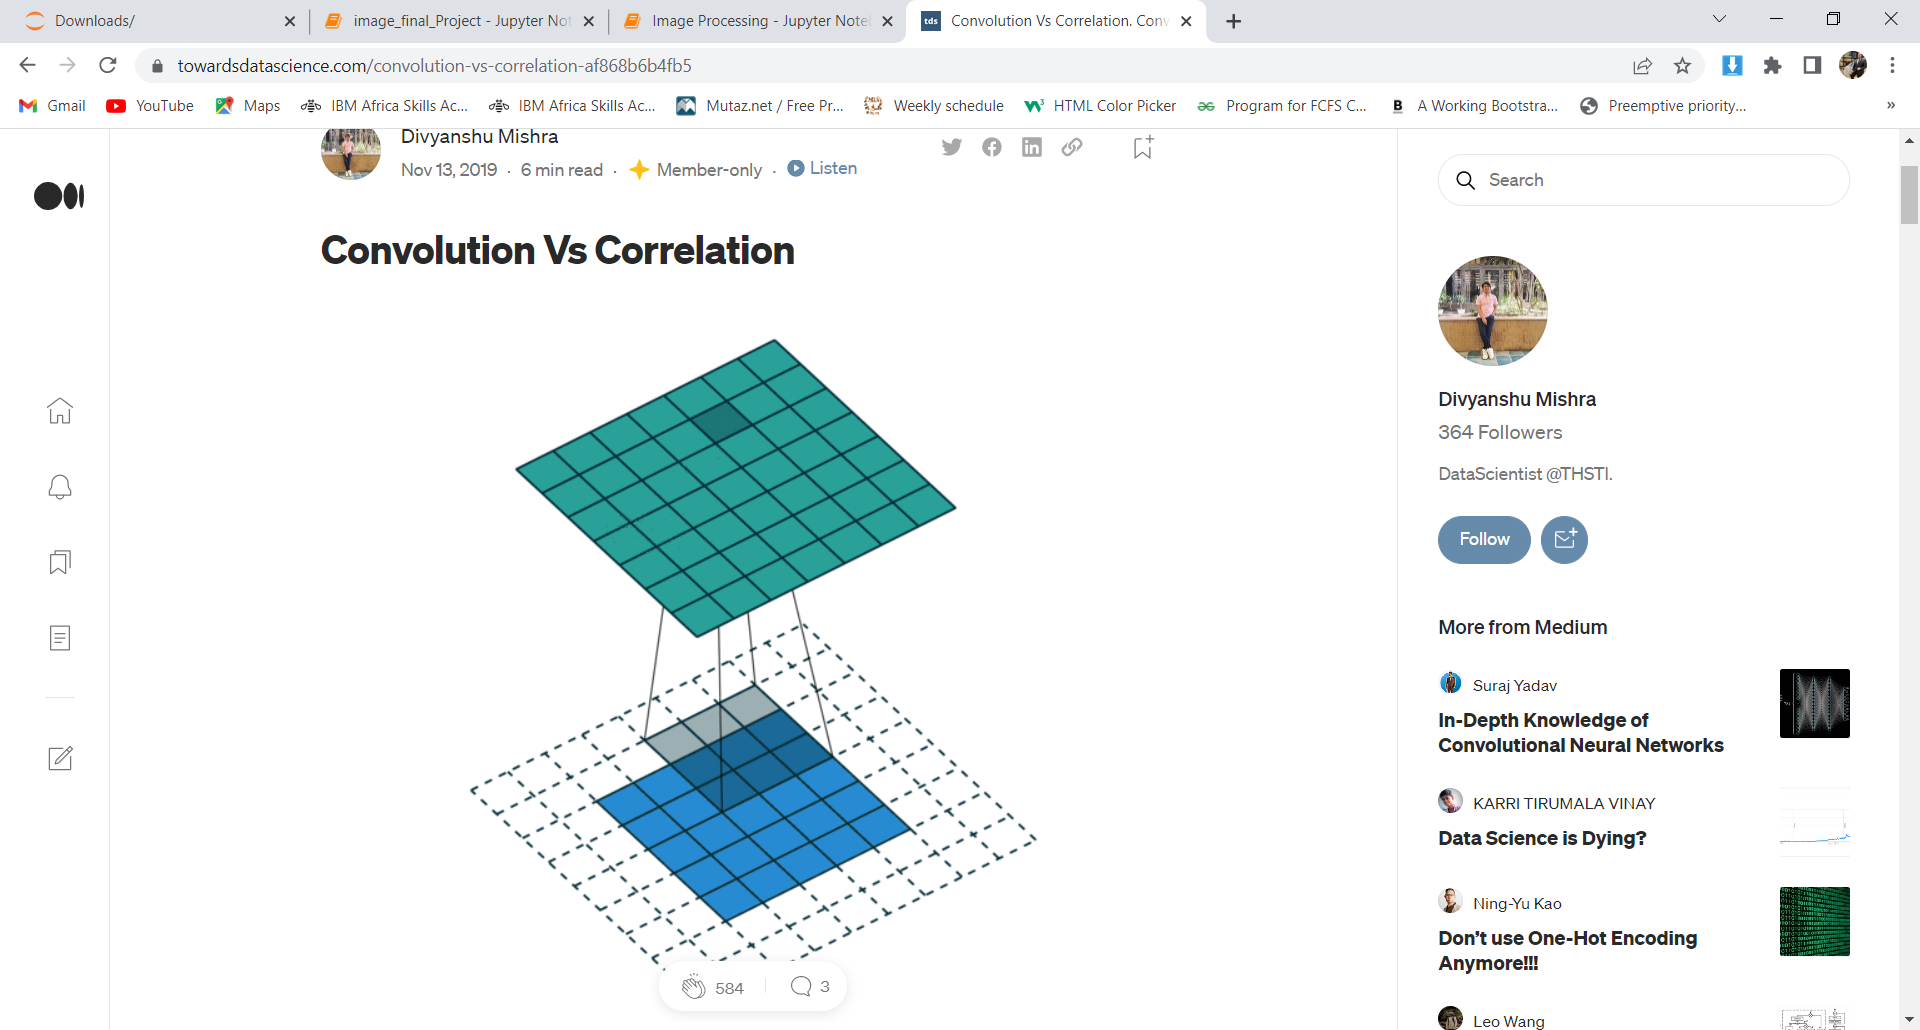

In [ ]:
    new(x,y) = (1*10)+(2*20)+(1*30)+(1*40)+(4*50)+(1*60)+(1+70)+(2*80)+(1*90)

# Padding 

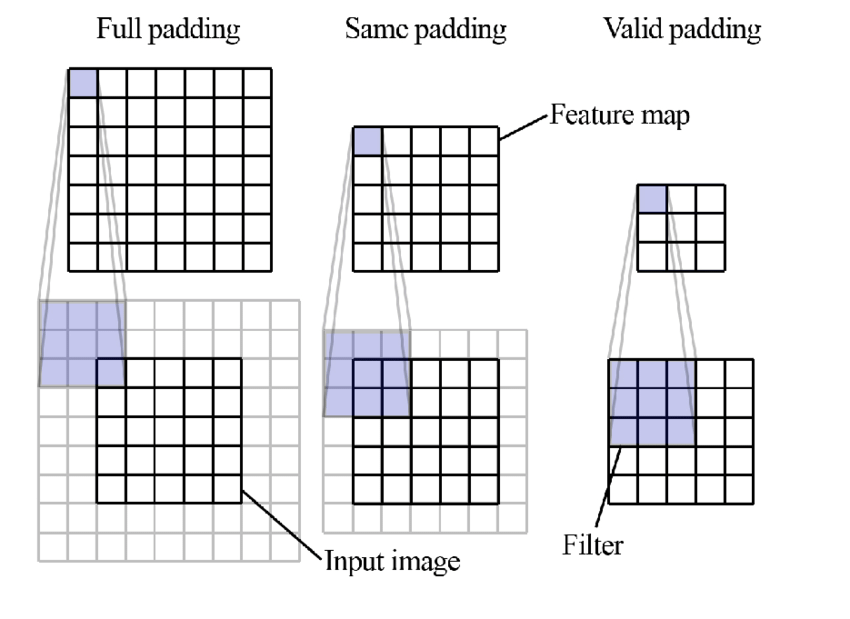

# Linear

In [ ]:
image = cv2.imread(r"F:\DataSets\Dataset_BUSI_with_GT\benign\benign (300).png", 0)

krnl_w = 3
krnl_h = 3

img_w = image.shape[0] #224
img_h = image.shape[1] #224

pad = np.zeros((img_w + krnl_w//2 , img_h + krnl_h//2 ))
pad[krnl_w//2: img_w + krnl_w//2, krnl_h//2: img_h + krnl_h//2] = image.copy()

# image = cv2.copyMakeBorder(image, 1, 1, 1, 1, cv2.BORDER_CONSTANT, None, value = 0)

new_image = np.zeros((img_w, img_h))

kernel = [[1,-2,1], [1, 4, 1], [1, -2 , 1]]
kernel = np.array(kernel)    

for r in range(0, pad.shape[0] - krnl_w + 1):
    for c in range(0, pad.shape[1] - krnl_h +1):
        matrix = pad[r: r + krnl_w, c: c + krnl_h]
        new_image[ r , c ] = np.sum(np.multiply(matrix, kernel))
    
plt.imshow(image,cmap = 'gray')
plt.show()
plt.imshow(new_image,cmap = 'gray')
plt.show()

# Nonlinear

In [ ]:
img = cv2.imread(r"F:\DataSets\KneeXrayData\KneeXrayData\ClsKLData\kneeKL299\val\4\9997856L.png",0)

krnl_w = 3
krnl_h = 3

img_w = image.shape[0]
img_h = image.shape[1]

pad = np.zeros( (img_w + krnl_w//2 , img_h + krnl_h//2 ))
pad[krnl_w//2: img_w + krnl_w//2, krnl_h//2: img_h + krnl_h//2] = image.copy()

# image = cv2.copyMakeBorder(image, 1, 1, 1, 1, cv2.BORDER_CONSTANT, None, value = 0)

new_image = np.zeros((img_w, img_h))

for r in range(0, pad.shape[0] - krnl_w + 1):
    for c in range(0, pad.shape[1] - krnl_h +1):
        matrix = pad[r: r + krnl_w, c: c + krnl_h]
        val = list(matrix.flatten())
        val = max(val)
        new_image[ r , c ] = (val)
    

plt.imshow(image,cmap = 'gray')
plt.show()
plt.imshow(new_image,cmap = 'gray')
plt.show()

# Unsharp Masking and Highboost Filtering (TASK OR them SOLVE IT )

# Unsharp masking
    Sharpen images consists of subtracting an unsharp (smoothed) version of an image from the original image 
    e.g., printing and publishing industry 

Steps

   1. Blur the original image

   2. Subtract the blurred image from the original (creates a mask)

   3. Add the mask to the original


In [ ]:
def unsharp_masking(im, kernal_size, mask_weight = 1, img_name = 'new_image'):
    #it's high boost if we change the mask_weight to be > 1 otherwise it's unsharp_masking
    if(mask_weight <= 0):
        mask_weight = 1
    blured_image = apply_nonlinear_filter(im, avg_filter, kernal_size)
    mask = im - blured_image
    return im + (mask * mask_weight)

In [ ]:
image = cv2.imread(r"F:\DataSets\KneeXrayData\KneeXrayData\ClsKLData\kneeKL299\val\4\9997856L.png",0)

krnl_w = 7
krnl_h = 7

wi = 1

img_w = image.shape[0]
img_h = image.shape[1]

pad = np.zeros( (img_w + krnl_w//2 , img_h + krnl_h//2 ))
pad[krnl_w//2: img_w + krnl_w//2, krnl_h//2: img_h + krnl_h//2] = image.copy()

# image = cv2.copyMakeBorder(image, 1, 1, 1, 1, cv2.BORDER_CONSTANT, None, value = 0)

new_image = np.zeros((img_w, img_h))

for r in range(0, pad.shape[0] - krnl_w + 1):
    for c in range(0, pad.shape[1] - krnl_h +1):
        matrix = pad[r: r + krnl_w, c: c + krnl_h]
        val = list(matrix.flatten())
        res = sum(val)//len(val)
        new_image[ r , c ] = (res)
        
mask = new_image - image
hi_un = image + (mask * wi)

plt.imshow(hi_un,cmap = 'gray')
plt.show()

# Fourier Transform

In [3]:
image = cv2.imread(r"F:\DataSets\Dataset BUSI _1\train\1\malignant (15).png", 0)

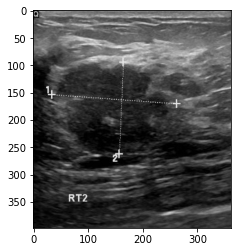

In [4]:
plt.imshow(image,cmap = 'gray')
plt.show()

In [12]:
f = np.fft.fft2(image)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20 * np.log(np.abs(fshift))
# print(fshift)

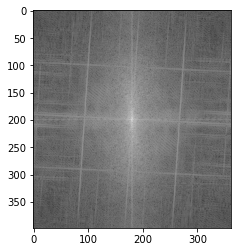

In [10]:
plt.imshow(magnitude_spectrum.real,cmap = 'gray')
plt.show()

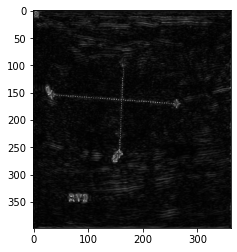

In [20]:
rows, cols = image.shape
crow,ccol = rows//2 , cols//2
mask = np.ones((rows, cols), np.uint8)
mask[crow-30:crow+30, ccol-30:ccol+30] = 0

fshift_filtered = fshift * mask
f_ishift = np.fft.ifftshift(fshift_filtered)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

plt.imshow(img_back.real,cmap = 'gray')
plt.show()

In [21]:
kernel = np.ones((3,3)) / 49
sz = (image.shape[0] - kernel.shape[0], image.shape[1] - kernel.shape[1])  # total amount of padding
kernel = np.pad(kernel, (((sz[0]+1)//2, sz[0]//2), ((sz[1]+1)//2, sz[1]//2)), 'constant')
f_k_shift = np.fft.ifftshift(kernel)

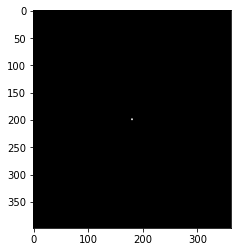

In [22]:
plt.imshow(kernel,cmap = 'gray')
plt.show()

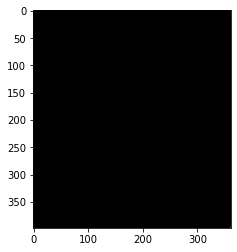

In [23]:
plt.imshow(f_k_shift,cmap = 'gray')
plt.show()

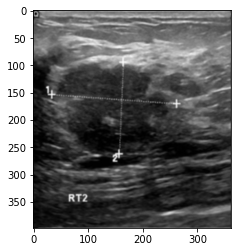

In [24]:
filtered = np.fft.ifft2(np.fft.fft2(image) * np.fft.fft2(f_k_shift)).real
plt.imshow(filtered,cmap = 'gray')
plt.show()

# Adding Noise and Remove It

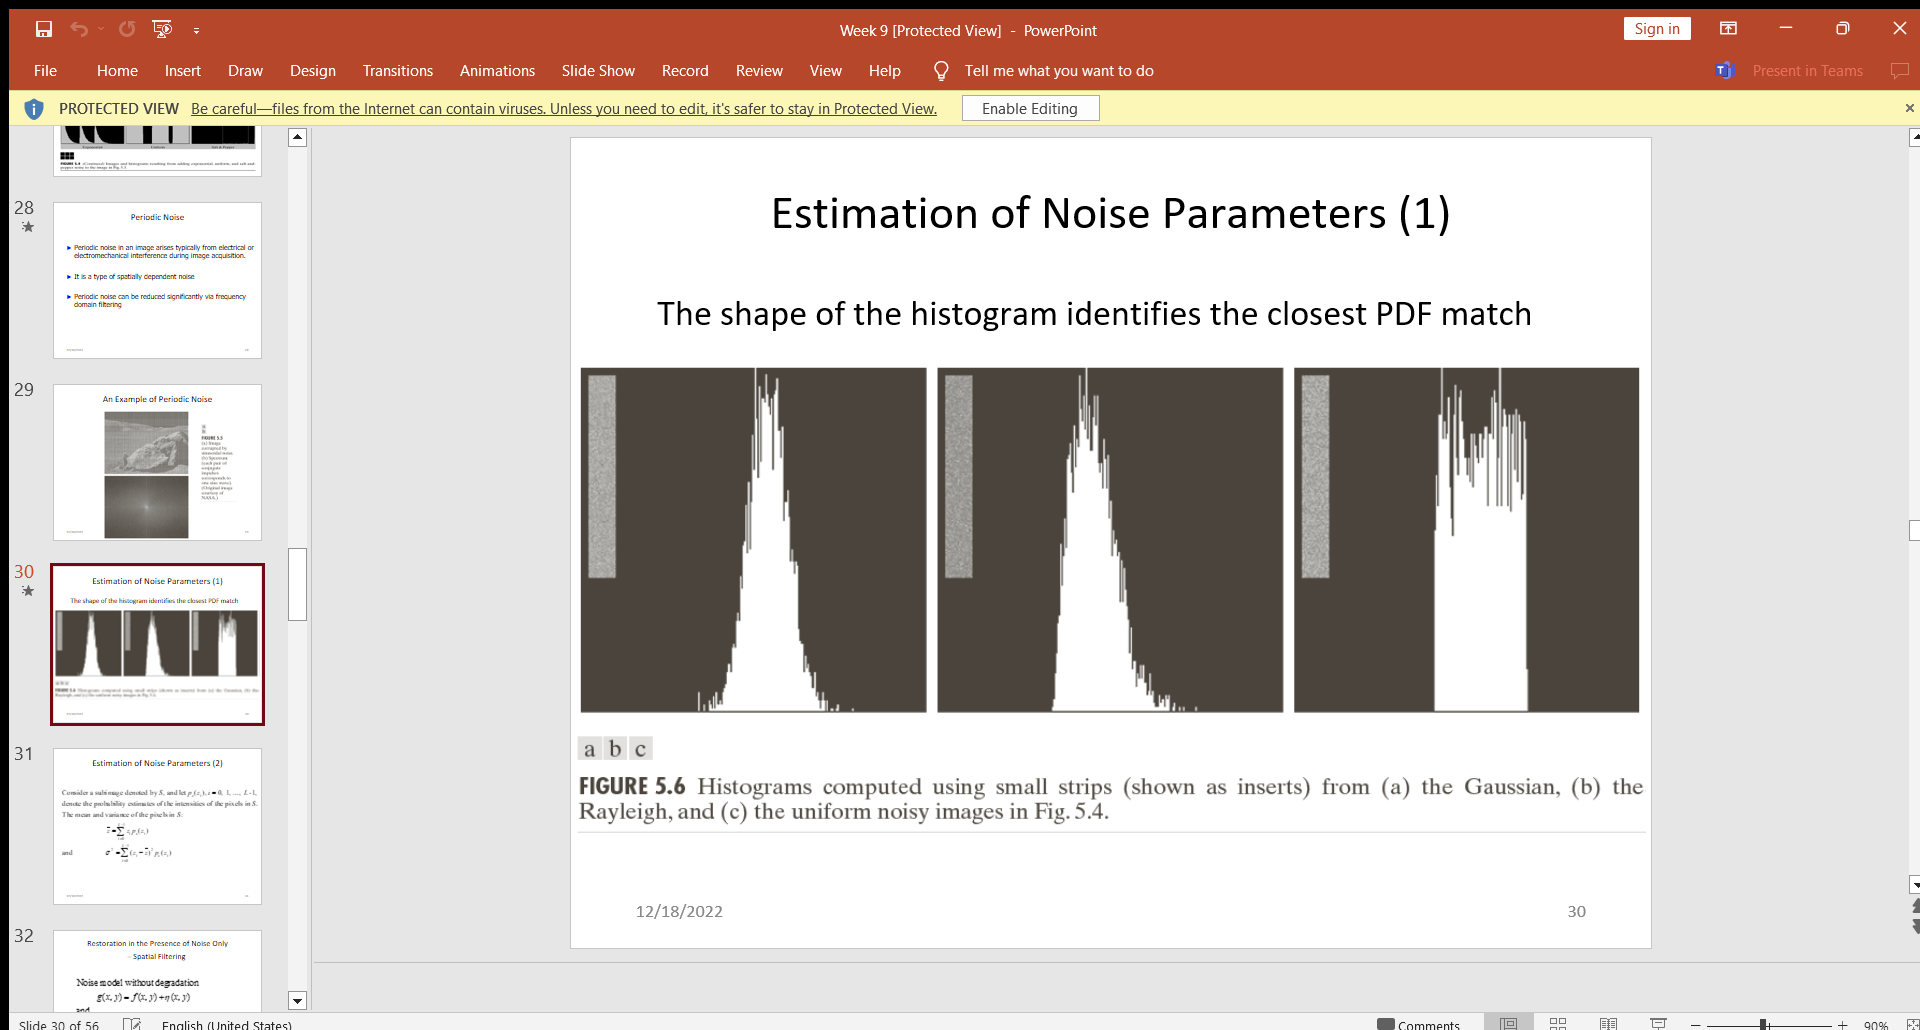

In [ ]:
image = cv2.imread(r"C:\Users\DR.Zoz\Desktop\2.JPG",0)

In [ ]:
plt.imshow(image,cmap = 'gray')
plt.show()

In [ ]:
def get_harmonic_man(my_list):
    sum = 0.0
    for i in my_list:
        sum += 1.0 / i
    return len(my_list) // sum

krnl_w = 3
krnl_h = 3

img_w = image.shape[0]
img_h = image.shape[1]

pad = np.zeros( (img_w + krnl_w//2 , img_h + krnl_h//2 ))
pad[krnl_w//2: img_w + krnl_w//2, krnl_h//2: img_h + krnl_h//2] = image.copy()
summ = 0
new_image = np.zeros((img_w, img_h))

for r in range(0, pad.shape[0] - krnl_w + 1):
    for c in range(0, pad.shape[1] - krnl_h +1):
        matrix = pad[r: r + krnl_w, c: c + krnl_h]
        val = list(matrix.flatten())
        res = get_harmonic_man(val)
        new_image[ r , c ] = res
            

plt.imshow(new_image,cmap = 'gray')
plt.show()

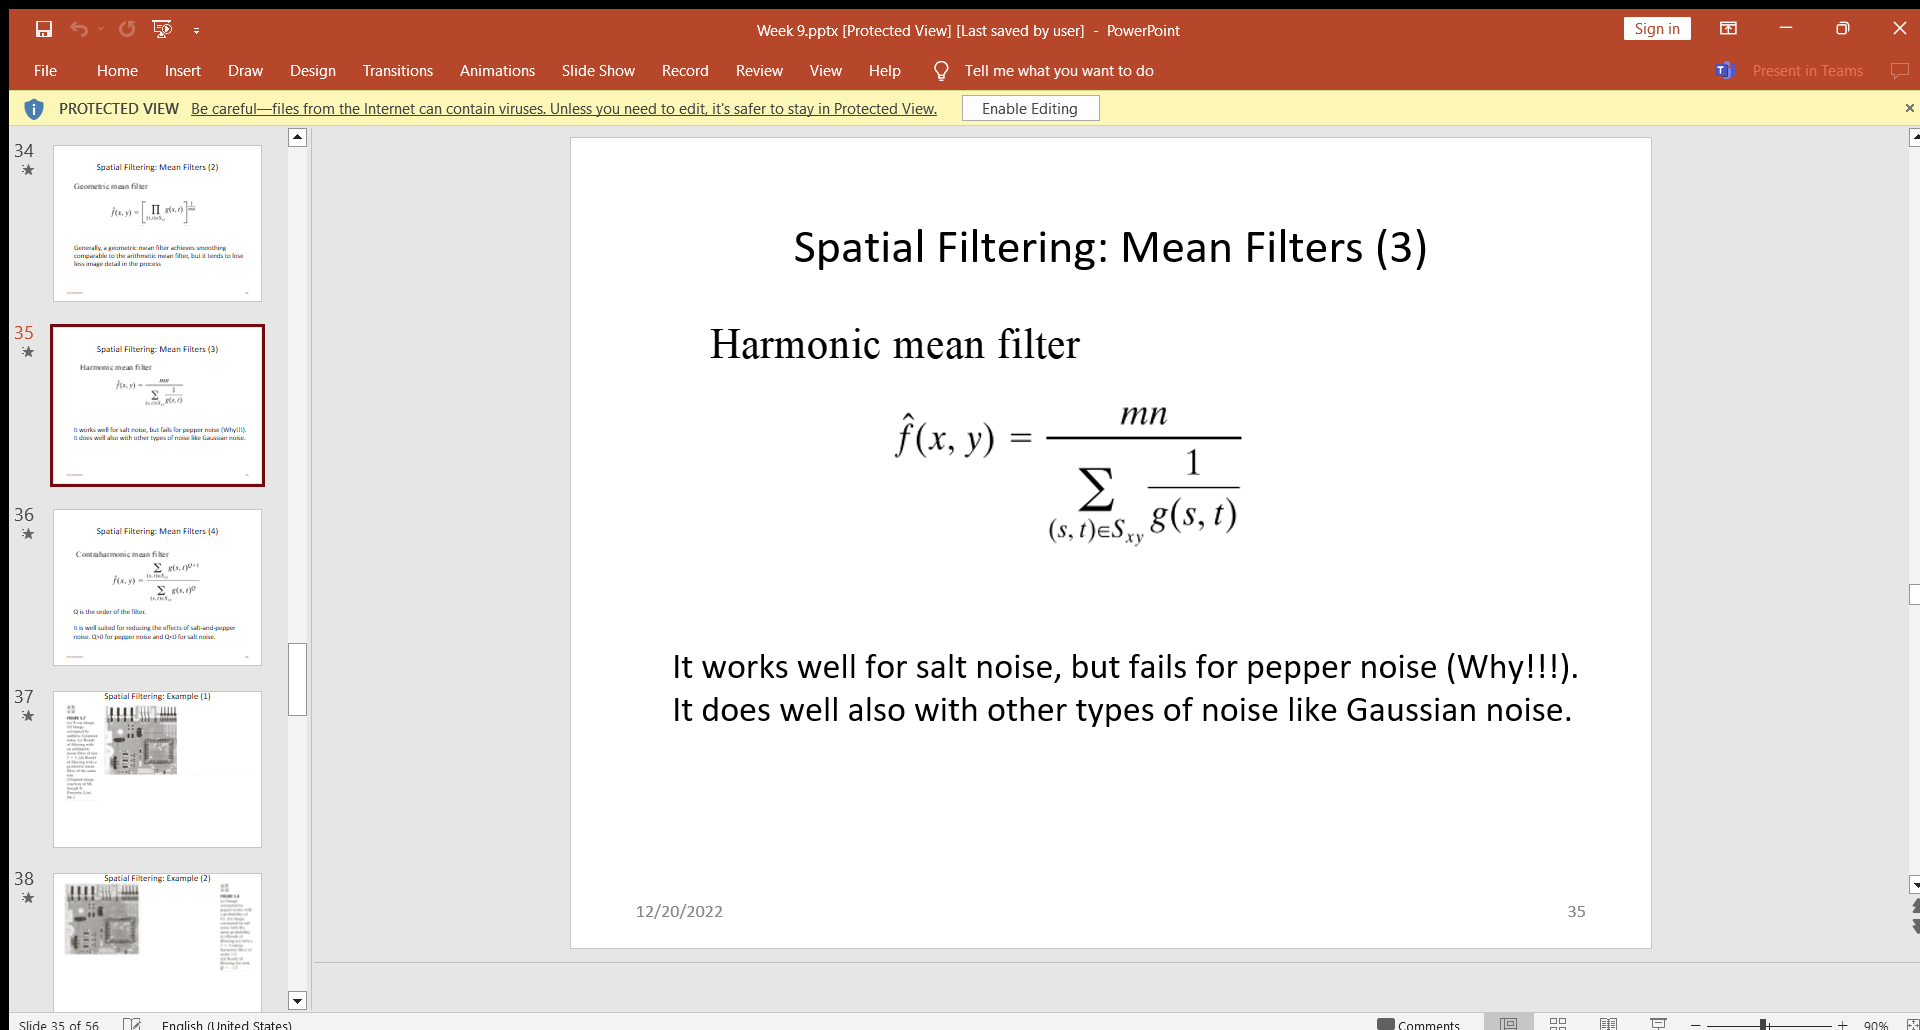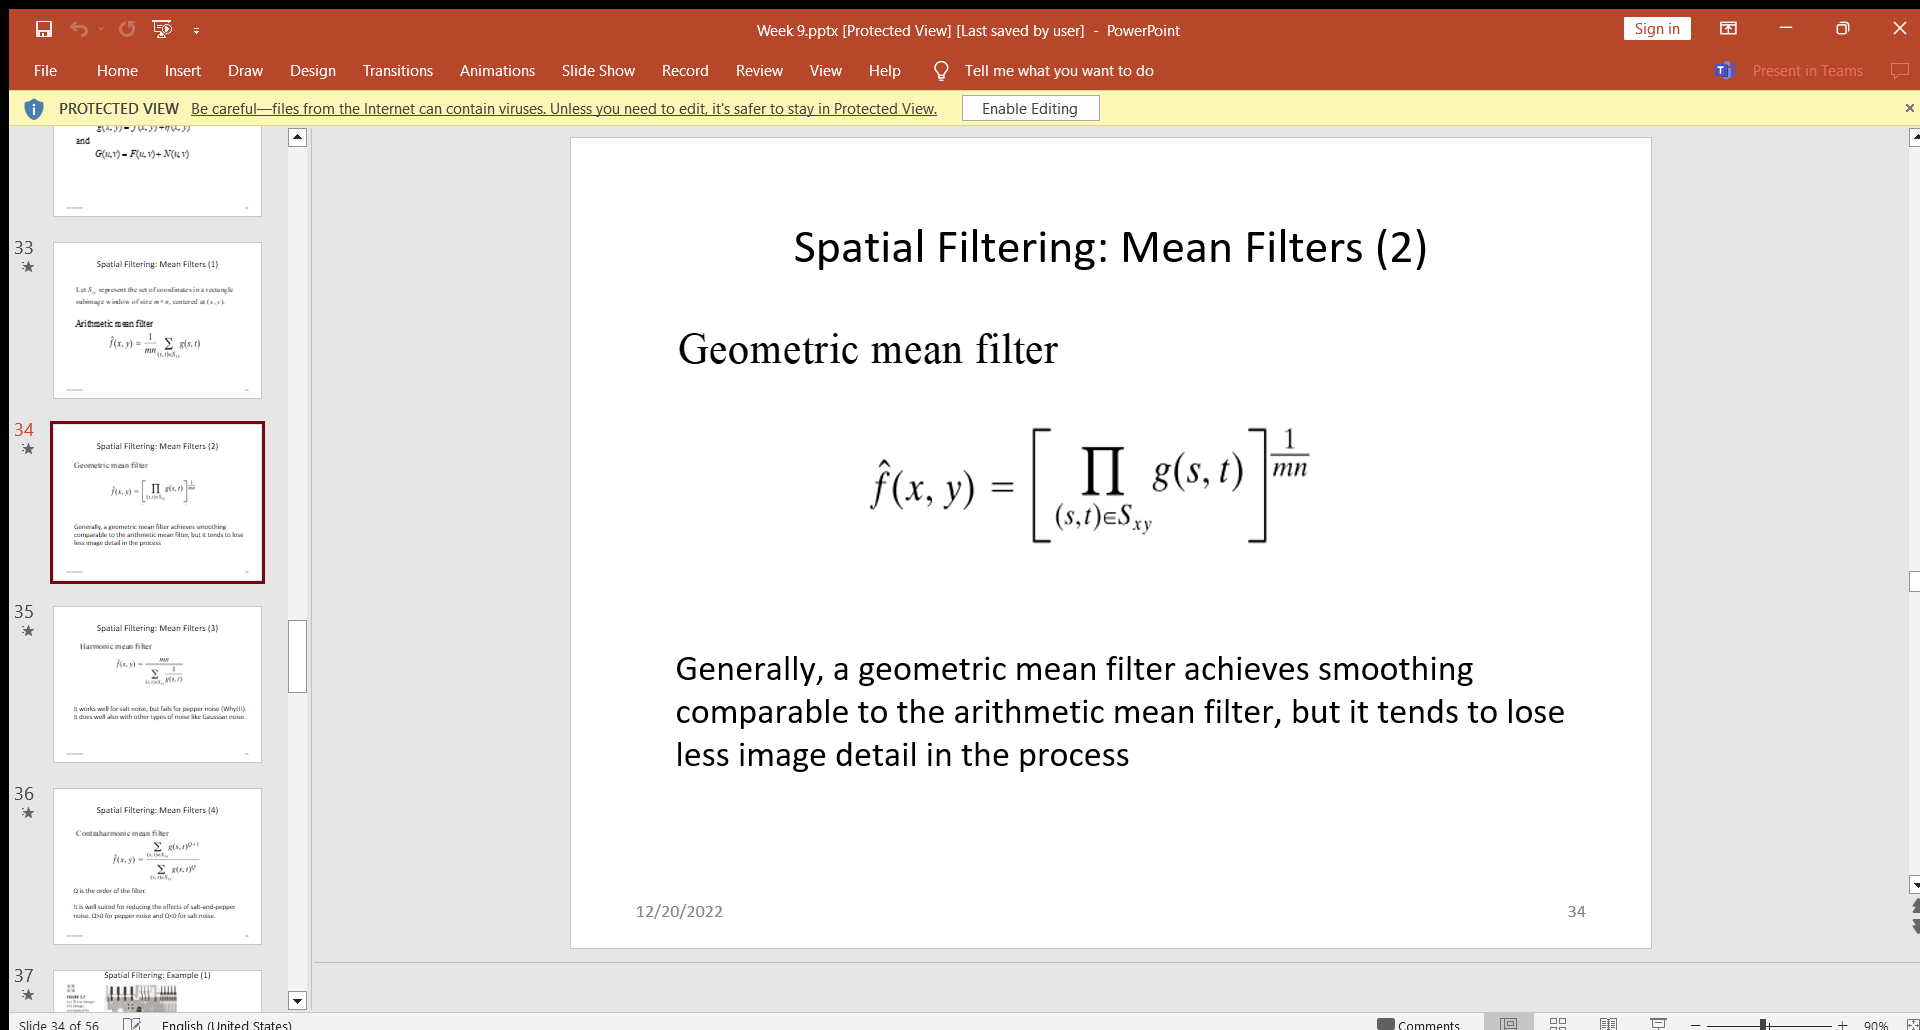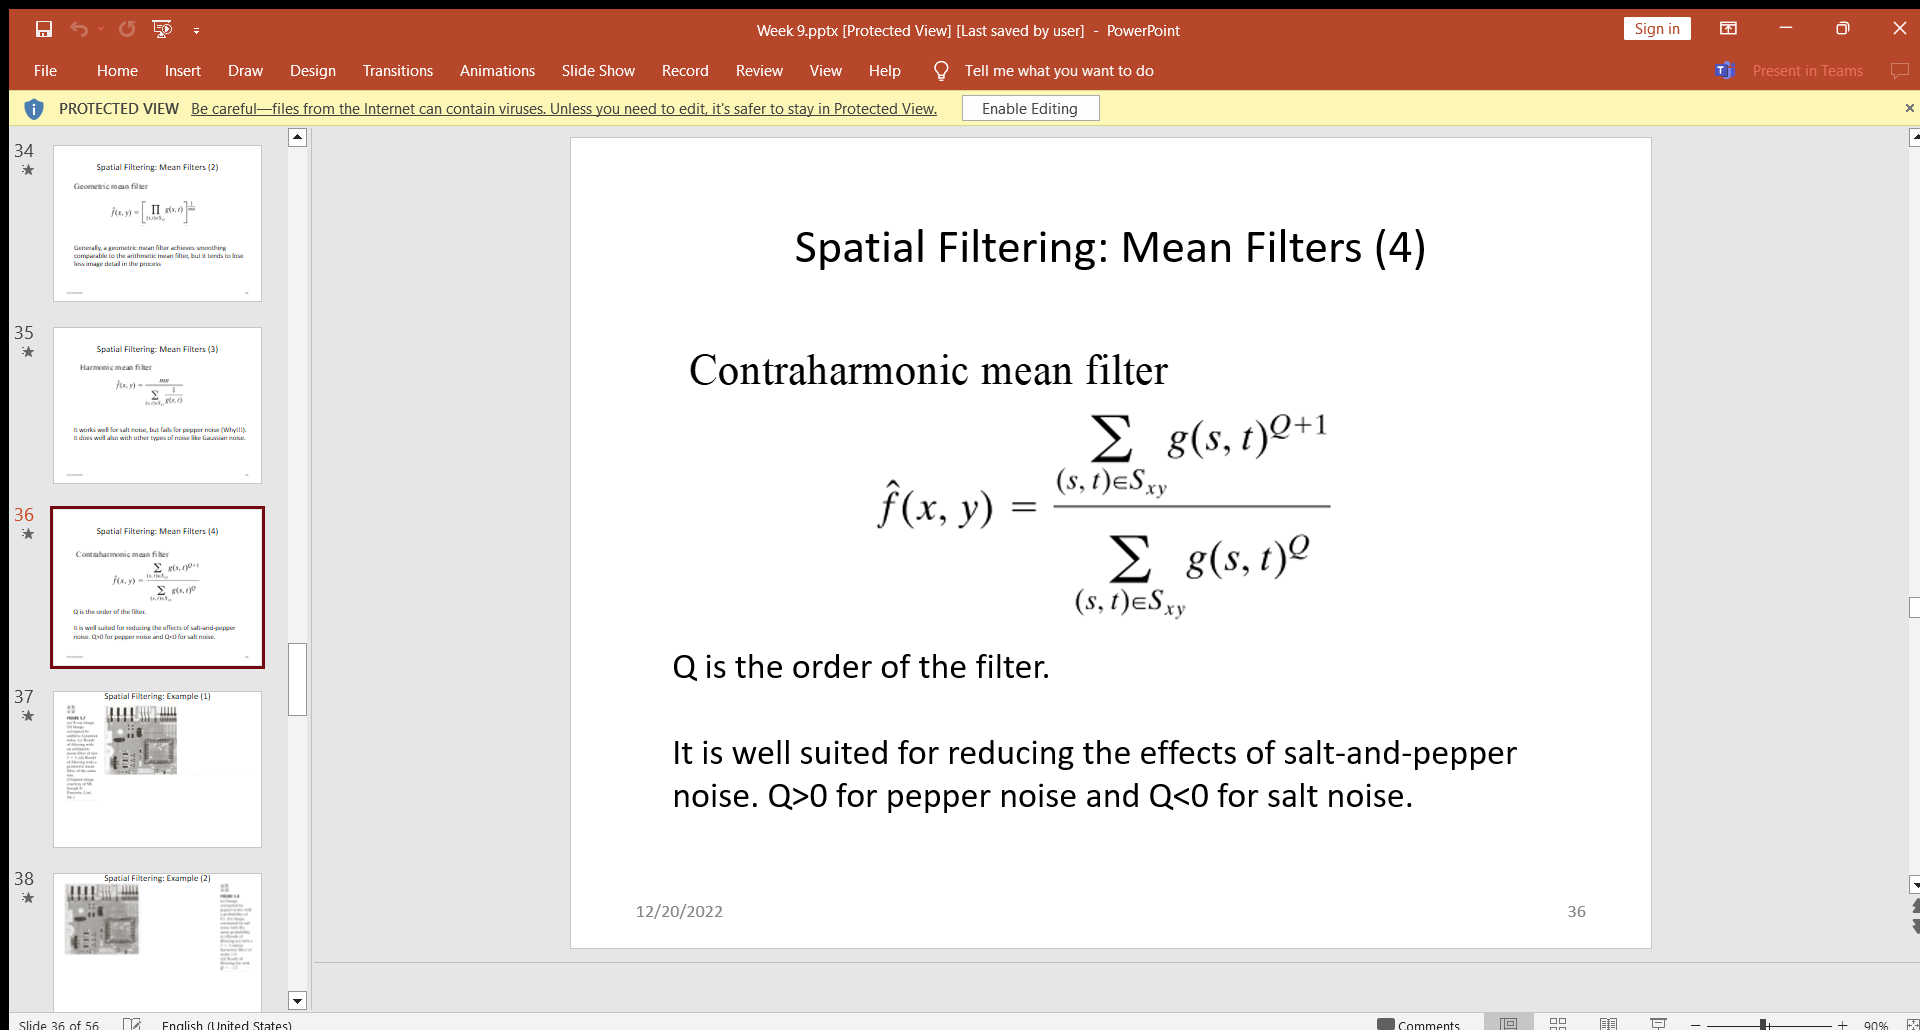

# Contraharmonic

In [ ]:
krnl_w = 3
krnl_h = 3

img_w = image.shape[0]
img_h = image.shape[1]

new_image = np.zeros((img_w, img_h))

Q = 1.5
for r in range(0, img_w - 3):
    for c in range(0, img_h - 3):
        matrix = image[r: r + krnl_w, c: c + krnl_h]
        val = list(matrix.flatten())
        
        nom = np.power(np.sum(val), Q + 1)
        denom = np.power(np.sum(val), Q)
        
        res = np.divide(nom, denom)
        new_image[ r , c ] = res
            

plt.imshow(new_image,cmap = 'gray')
plt.show()

In [ ]:
#import numpy
from PIL import Image
def median_filter(data, filter_size):
    temp = []
    indexer = filter_size // 2
    data_final = []
    data_final = np.zeros((len(data),len(data[0])))
    for i in range(len(data)):
        for j in range(len(data[0])):
            for z in range(filter_size):
                if i + z - indexer < 0 or i + z - indexer > len(data) - 1:
                    for c in range(filter_size):
                        temp.append(0)
                else:
                    if j + z - indexer < 0 or j + indexer > len(data[0]) - 1:
                        temp.append(0)
                    else:
                        for k in range(filter_size):
                            temp.append(data[i + z - indexer][j + k - indexer])

            temp.sort()
            data_final[i][j] = temp[len(temp) // 2]
            temp = []
    return data_final



In [ ]:
image = cv2.imread(r"C:\Users\DR.Zoz\Desktop\1.png")
arr = np.array(image)
removed_noise = median_filter(arr, 3)

#img = Image.fromarray(removed_noise)
cv2_imshow(removed_noise)


In [ ]:
print(image)

In [2]:
5**5

3125